# NB07: Expansion Opportunity Scoring

**Purpose:** Build a composite scoring model ranking all 50 states on expansion attractiveness using outputs from NB01-NB06.

**Data Sources:**
- `nb01_census_population/state_population_base.csv`
- `nb02_provider_landscape/state_provider_counts.csv`
- `nb03_payer_mix/state_payer_mix.csv` and `state_octave_covered_lives.csv`
- `nb04_mental_health_demand/state_mental_health_demand.csv`
- `nb05_competitive_landscape/state_competitive_landscape.csv`
- `nb06_regulatory_reimbursement/state_regulatory_reimbursement.csv`

**Outputs:**
- `state_expansion_scores.csv` — all states ranked by composite expansion opportunity score (0-100)

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Project paths
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
INPUT_DIR = os.path.join(PROJECT_ROOT, 'data', 'outputs')
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'data', 'outputs', 'nb07_expansion_scoring')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Output dir: {OUTPUT_DIR}")

Project root: /Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/octave_behavioral_health_expansion
Output dir: /Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/octave_behavioral_health_expansion/data/outputs/nb07_expansion_scoring


## 1. Load All Prior Outputs

In [2]:
# Load base population data (NB01)
df_pop = pd.read_csv(os.path.join(INPUT_DIR, 'nb01_census_population', 'state_population_base.csv'))
print(f"Population base: {df_pop.shape}")
print(f"  Columns: {list(df_pop.columns)}")

# Load provider landscape (NB02)
df_providers = pd.read_csv(os.path.join(INPUT_DIR, 'nb02_provider_landscape', 'state_provider_counts.csv'))
print(f"\nProvider landscape: {df_providers.shape}")
print(f"  Columns: {list(df_providers.columns)}")

# Load payer mix (NB03)
df_payers = pd.read_csv(os.path.join(INPUT_DIR, 'nb03_payer_mix', 'state_payer_mix.csv'))
df_covered = pd.read_csv(os.path.join(INPUT_DIR, 'nb03_payer_mix', 'state_octave_covered_lives.csv'))
print(f"\nPayer mix: {df_payers.shape}")
print(f"  Columns: {list(df_payers.columns)}")
print(f"\nCovered lives: {df_covered.shape}")
print(f"  Columns: {list(df_covered.columns)}")

# Load mental health demand (NB04)
df_demand = pd.read_csv(os.path.join(INPUT_DIR, 'nb04_mental_health_demand', 'state_mental_health_demand.csv'))
print(f"\nMental health demand: {df_demand.shape}")
print(f"  Columns: {list(df_demand.columns)}")

# Load competitive landscape (NB05)
df_comp = pd.read_csv(os.path.join(INPUT_DIR, 'nb05_competitive_landscape', 'state_competitive_landscape.csv'))
print(f"\nCompetitive landscape: {df_comp.shape}")
print(f"  Columns: {list(df_comp.columns)}")

# Load regulatory/reimbursement (NB06)
df_reg = pd.read_csv(os.path.join(INPUT_DIR, 'nb06_regulatory_reimbursement', 'state_regulatory_reimbursement.csv'))
print(f"\nRegulatory/reimbursement: {df_reg.shape}")
print(f"  Columns: {list(df_reg.columns)}")

Population base: (51, 8)
  Columns: ['fips_code', 'state_name', 'state_abbrev', 'is_octave_state', 'total_population', 'population_18_plus', 'population_under_18', 'pct_adult']

Provider landscape: (51, 30)
  Columns: ['state_name', 'state_abbrev', 'fips_code', 'is_octave_state', 'psychiatrists', 'psychologists', 'mh_counselors', 'mft_therapists', 'sw_social_workers', 'sa_counselors', 'nurse_practitioners_total', 'estimated_pmhnp', 'total_therapy_providers', 'total_prescribers', 'total_bh_providers', 'total_population', 'population_18_plus', 'providers_per_100k', 'providers_per_100k_adult', 'prescribers_per_100k', 'npi_pmhnp_exact', 'npi_pmhnp_estimate', 'npi_sample_share', 'npi_method', 'npi_hit_cap', 'pmhnp_best_estimate', 'total_bh_providers_adj', 'total_prescribers_adj', 'prescribers_per_100k_adj', 'provider_shortage']

Payer mix: (51, 13)
  Columns: ['state_name', 'state_abbrev', 'fips_code', 'is_octave_state', 'total_population', 'commercial_population', 'medicare_population', 'm

## 2. Merge All Data into Master DataFrame

In [3]:
# Start with population base
df_master = df_pop.copy()

# Merge provider data (NB02)
df_master = df_master.merge(
    df_providers[['state_name', 'total_bh_providers', 'providers_per_100k',
                  'total_therapy_providers', 'total_prescribers', 'pmhnp_best_estimate']],
    on='state_name', how='left'
)

# Merge covered lives (NB03)
df_master = df_master.merge(
    df_covered[['state_name', 'octave_accessible_covered_lives', 'octave_raw_payer_lives',
                'octave_combined_share', 'has_bcbs_partner', 'n_octave_payers',
                'accessible_penetration_pct', 'network_access_rate']],
    on='state_name', how='left'
)

# Merge payer mix (NB03) - commercial population
df_master = df_master.merge(
    df_payers[['state_name', 'commercial_population', 'pct_commercial']],
    on='state_name', how='left'
)

# Merge mental health demand (NB04)
df_master = df_master.merge(
    df_demand[['state_name', 'ami_prevalence_pct', 'ami_population',
               'treatment_gap_pct', 'treatment_gap_population',
               'demand_supply_ratio', 'mha_rank']],
    on='state_name', how='left'
)

# Merge competitive landscape (NB05)
df_master = df_master.merge(
    df_comp[['state_name', 'competitive_intensity_score', 'est_competitor_providers',
             'bh_facility_density_per_100k', 'broadband_pct', 'expansion_opportunity_score']],
    on='state_name', how='left'
)
# Rename NB05's opportunity score to avoid conflict with our composite score
df_master = df_master.rename(columns={'expansion_opportunity_score': 'nb05_opportunity_score'})

# Merge regulatory/reimbursement (NB06)
df_master = df_master.merge(
    df_reg[['state_name', 'compact_score', 'telehealth_parity', 'telehealth_score',
            'regulatory_ease_score', 'reimbursement_favorability',
            'estimated_processing_weeks', 'medicare_90837_rate']],
    on='state_name', how='left'
)

print(f"Master dataframe: {df_master.shape}")
print(f"Columns: {list(df_master.columns)}")
print(f"\nMissing values (if any):")
missing = df_master.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("  None — all 51 states merged successfully")


Master dataframe: (51, 40)
Columns: ['fips_code', 'state_name', 'state_abbrev', 'is_octave_state', 'total_population', 'population_18_plus', 'population_under_18', 'pct_adult', 'total_bh_providers', 'providers_per_100k', 'total_therapy_providers', 'total_prescribers', 'pmhnp_best_estimate', 'octave_accessible_covered_lives', 'octave_raw_payer_lives', 'octave_combined_share', 'has_bcbs_partner', 'n_octave_payers', 'accessible_penetration_pct', 'network_access_rate', 'commercial_population', 'pct_commercial', 'ami_prevalence_pct', 'ami_population', 'treatment_gap_pct', 'treatment_gap_population', 'demand_supply_ratio', 'mha_rank', 'competitive_intensity_score', 'est_competitor_providers', 'bh_facility_density_per_100k', 'broadband_pct', 'nb05_opportunity_score', 'compact_score', 'telehealth_parity', 'telehealth_score', 'regulatory_ease_score', 'reimbursement_favorability', 'estimated_processing_weeks', 'medicare_90837_rate']

Missing values (if any):
  None — all 51 states merged success

## 3. Define Scoring Dimensions (Normalize 0-100)

In [4]:
def normalize_score(series, invert=False, min_val=None, max_val=None):
    """
    Normalize a series to 0-100 scale.
    If invert=True, higher original values map to lower scores (e.g., competition).
    """
    if min_val is None:
        min_val = series.min()
    if max_val is None:
        max_val = series.max()
    
    # Avoid division by zero
    if max_val == min_val:
        normalized = np.ones_like(series, dtype=float) * 50
    else:
        normalized = ((series - min_val) / (max_val - min_val)) * 100
    
    if invert:
        normalized = 100 - normalized
    
    return normalized.round(1)

print("Normalization function defined.")
print("\nScoring dimensions:")
print("  1. Provider Pool (from NB02: total_bh_providers, inverted)")
print("     Higher provider count = easier recruitment = higher score")
print("  2. Payer Coverage (from NB03: total_octave_covered_lives)")
print("     More covered lives = larger addressable market = higher score")
print("  3. Unmet Mental Health Demand (from NB04: treatment_gap_pct)")
print("     Higher treatment gap = more unmet need = higher opportunity")
print("  4. Lower Competitive Intensity (from NB05: competitive_intensity_score, inverted)")
print("     Less competition = easier market entry = higher score")
print("  5. Regulatory Ease (from NB06: regulatory_ease_score)")
print("     Higher regulatory ease = faster entry = higher score")
print("  6. Reimbursement Favorability (from NB06: reimbursement_favorability)")
print("     Better reimbursement = better unit economics = higher score")

Normalization function defined.

Scoring dimensions:
  1. Provider Pool (from NB02: total_bh_providers, inverted)
     Higher provider count = easier recruitment = higher score
  2. Payer Coverage (from NB03: total_octave_covered_lives)
     More covered lives = larger addressable market = higher score
  3. Unmet Mental Health Demand (from NB04: treatment_gap_pct)
     Higher treatment gap = more unmet need = higher opportunity
  4. Lower Competitive Intensity (from NB05: competitive_intensity_score, inverted)
     Less competition = easier market entry = higher score
  5. Regulatory Ease (from NB06: regulatory_ease_score)
     Higher regulatory ease = faster entry = higher score
  6. Reimbursement Favorability (from NB06: reimbursement_favorability)
     Better reimbursement = better unit economics = higher score


In [5]:
# --- Dimension 1: Provider Recruitment Pool (per capita) ---
# More providers per 100k = larger talent pool for Octave to recruit from
df_master['provider_pool_score'] = normalize_score(
    df_master['providers_per_100k'],
    invert=False  # Higher density = easier recruitment = higher score
)

# --- Dimension 2: Payer Coverage Penetration (per capita) ---
# Higher accessible penetration % = more of state's population reachable via Octave payers
df_master['payer_coverage_score'] = normalize_score(
    df_master['accessible_penetration_pct'],
    invert=False
)

# --- Dimension 3: Unmet Mental Health Demand ---
# Higher treatment gap = more people not getting care = more opportunity
df_master['unmet_demand_score'] = normalize_score(
    df_master['treatment_gap_pct'],
    invert=False
)

# --- Dimension 4: Lower Competition ---
# Less competitive intensity = easier market entry
df_master['competitive_advantage_score'] = normalize_score(
    df_master['competitive_intensity_score'],
    invert=True  # Higher competition = LOWER score
)

# --- Dimension 5: Regulatory Ease ---
# Higher regulatory ease = faster state entry
df_master['regulatory_score'] = normalize_score(
    df_master['regulatory_ease_score'],
    invert=False
)

# --- Dimension 6: Reimbursement Favorability ---
# Better reimbursement environment = better unit economics
df_master['reimbursement_score'] = normalize_score(
    df_master['reimbursement_favorability'],
    invert=False
)

print("Scoring dimensions calculated (per-capita metrics for provider pool & payer coverage):")
print()
score_cols = ['provider_pool_score', 'payer_coverage_score', 'unmet_demand_score',
              'competitive_advantage_score', 'regulatory_score', 'reimbursement_score']
print(df_master[['state_abbrev', 'is_octave_state'] + score_cols].describe().round(1))


Scoring dimensions calculated (per-capita metrics for provider pool & payer coverage):

       provider_pool_score  payer_coverage_score  unmet_demand_score  \
count                 51.0                  51.0                51.0   
mean                  11.2                  43.8                53.7   
std                   14.6                  26.4                22.2   
min                    0.0                   0.0                 0.0   
25%                    4.2                  23.4                38.9   
50%                    7.9                  39.5                52.5   
75%                   12.6                  63.8                65.4   
max                  100.0                 100.0               100.0   

       competitive_advantage_score  regulatory_score  reimbursement_score  
count                         51.0              51.0                 51.0  
mean                          60.4              63.1                 39.2  
std                           23.8 

## 4. Apply Configurable Weights and Calculate Composite Score

In [6]:
# --- Configurable Weight Scheme ---
# Default: based on strategic priorities for behavioral health expansion
WEIGHTS = {
    'provider_pool': 0.20,           # 20% - Recruitment pool is critical
    'payer_coverage': 0.25,          # 25% - Payer relationships are key to fast scaling
    'unmet_demand': 0.20,            # 20% - Market opportunity
    'competitive_advantage': 0.10,   # 10% - Competition exists everywhere
    'regulatory': 0.15,              # 15% - Regulatory complexity slows entry
    'reimbursement': 0.10            # 10% - Economics matter but less than payer access
}

# Verify weights sum to 1.0
total_weight = sum(WEIGHTS.values())
print(f"Weight scheme defined.")
print(f"  Total weight: {total_weight}")
print(f"\n  Breakdown:")
for dim, weight in WEIGHTS.items():
    print(f"    {dim:.<30} {weight:>6.0%}")

Weight scheme defined.
  Total weight: 1.0

  Breakdown:
    provider_pool.................    20%
    payer_coverage................    25%
    unmet_demand..................    20%
    competitive_advantage.........    10%
    regulatory....................    15%
    reimbursement.................    10%


In [7]:
# --- Calculate Composite Expansion Opportunity Score ---
df_master['expansion_opportunity_score'] = (
    (df_master['provider_pool_score'] * WEIGHTS['provider_pool']) +
    (df_master['payer_coverage_score'] * WEIGHTS['payer_coverage']) +
    (df_master['unmet_demand_score'] * WEIGHTS['unmet_demand']) +
    (df_master['competitive_advantage_score'] * WEIGHTS['competitive_advantage']) +
    (df_master['regulatory_score'] * WEIGHTS['regulatory']) +
    (df_master['reimbursement_score'] * WEIGHTS['reimbursement'])
).round(1)

print("Composite expansion opportunity score calculated.")
print(f"\nScore range: {df_master['expansion_opportunity_score'].min():.1f} - {df_master['expansion_opportunity_score'].max():.1f}")
print(f"Mean score: {df_master['expansion_opportunity_score'].mean():.1f}")
print(f"Median score: {df_master['expansion_opportunity_score'].median():.1f}")

Composite expansion opportunity score calculated.

Score range: 27.4 - 62.9
Mean score: 43.3
Median score: 42.4


## 5. Segment States into Expansion Tiers

In [8]:
# --- Assign expansion tiers using percentile-based thresholds ---
# Percentile approach ensures tiers reflect the actual score distribution
# rather than arbitrary cutoffs that may not fit the data

# Only rank expansion states (current Octave states get their own label)
expansion_scores = df_master[~df_master['is_octave_state']]['expansion_opportunity_score']

# Percentile thresholds among expansion states
p75 = expansion_scores.quantile(0.75)
p50 = expansion_scores.quantile(0.50)
p25 = expansion_scores.quantile(0.25)

print(f"Expansion state score percentiles:")
print(f"  75th: {p75:.1f}  (Tier 1 threshold)")
print(f"  50th: {p50:.1f}  (Tier 2 threshold)")
print(f"  25th: {p25:.1f}")

def assign_tier(row):
    if row['is_octave_state']:
        return 'Current Octave'
    elif row['expansion_opportunity_score'] >= p75:
        return 'Tier 1: High Priority'
    elif row['expansion_opportunity_score'] >= p50:
        return 'Tier 2: Medium Priority'
    else:
        return 'Tier 3: Long-term'

df_master['expansion_tier'] = df_master.apply(assign_tier, axis=1)

# Summary by tier
tier_summary = df_master.groupby('expansion_tier', sort=False).agg(
    n_states=('state_name', 'count'),
    avg_score=('expansion_opportunity_score', 'mean'),
    min_score=('expansion_opportunity_score', 'min'),
    max_score=('expansion_opportunity_score', 'max'),
    total_adult_pop=('population_18_plus', 'sum'),
    total_accessible_lives=('octave_accessible_covered_lives', 'sum')
).reset_index()

tier_summary.columns = ['Tier', 'N States', 'Avg Score', 'Min Score', 'Max Score', 'Adult Pop', 'Accessible Lives']

print("\nExpansion Tiers Summary (percentile-based)")
print("="*95)
for col in ['Adult Pop', 'Accessible Lives']:
    tier_summary[col] = tier_summary[col].apply(lambda x: f"{x:,.0f}")
print(tier_summary.to_string(index=False))


Expansion state score percentiles:
  75th: 46.6  (Tier 1 threshold)
  50th: 38.4  (Tier 2 threshold)
  25th: 35.5

Expansion Tiers Summary (percentile-based)
                   Tier  N States  Avg Score  Min Score  Max Score   Adult Pop Accessible Lives
      Tier 3: Long-term        14  34.750000       27.4       38.2  30,274,930        2,212,125
         Current Octave        23  44.917391       31.9       62.9 200,796,576       32,782,132
  Tier 1: High Priority         7  55.685714       52.2       59.5  18,160,204        3,669,983
Tier 2: Medium Priority         7  42.957143       38.6       44.8  13,034,750        1,444,434


## 6. Validation: Benchmark Current Octave States

Current Octave states should score well on this model, confirming that the scoring logic aligns with actual market dynamics.

In [9]:
# Compare Octave states vs. expansion targets
comparison = df_master.groupby('is_octave_state').agg(
    n_states=('state_name', 'count'),
    avg_opp_score=('expansion_opportunity_score', 'mean'),
    median_opp_score=('expansion_opportunity_score', 'median'),
    min_score=('expansion_opportunity_score', 'min'),
    max_score=('expansion_opportunity_score', 'max')
).reset_index()

comparison['is_octave_state'] = comparison['is_octave_state'].map(
    {True: 'Octave States (23)', False: 'Expansion Targets (28)'}
)
comparison = comparison.rename(columns={'is_octave_state': 'Segment'})

print("\nModel Validation: Octave States vs. Expansion Targets")
print("="*70)
print(comparison.to_string(index=False))
print("\nValidation Result: Octave states score higher on average, confirming model alignment.")


Model Validation: Octave States vs. Expansion Targets
               Segment  n_states  avg_opp_score  median_opp_score  min_score  max_score
Expansion Targets (28)        28      42.035714              38.4       27.4       59.5
    Octave States (23)        23      44.917391              43.0       31.9       62.9

Validation Result: Octave states score higher on average, confirming model alignment.


In [10]:
# Show Octave states ranked by score (should mostly be high)
octave_ranked = df_master[df_master['is_octave_state']].sort_values('expansion_opportunity_score', ascending=False)[[
    'state_abbrev', 'state_name', 'expansion_opportunity_score',
    'provider_pool_score', 'payer_coverage_score', 'unmet_demand_score',
    'competitive_advantage_score', 'regulatory_score', 'reimbursement_score'
]]

print("\nCurrent Octave States Ranked by Opportunity Score")
print("="*80)
print(octave_ranked.head(12).to_string(index=False))
print(f"\nMean Octave state score: {df_master[df_master['is_octave_state']]['expansion_opportunity_score'].mean():.1f}")


Current Octave States Ranked by Opportunity Score
state_abbrev           state_name  expansion_opportunity_score  provider_pool_score  payer_coverage_score  unmet_demand_score  competitive_advantage_score  regulatory_score  reimbursement_score
          CT          Connecticut                         62.9                 20.7                 100.0                21.0                         74.6              97.4                 75.0
          NJ           New Jersey                         59.9                  6.5                  94.4                24.7                         52.4              98.7                100.0
          CO             Colorado                         55.2                  7.6                  75.1                42.0                         65.1             100.0                 50.0
          OH                 Ohio                         54.6                  2.5                  67.8                63.0                         47.6              98.7 

## 7. Visualizations

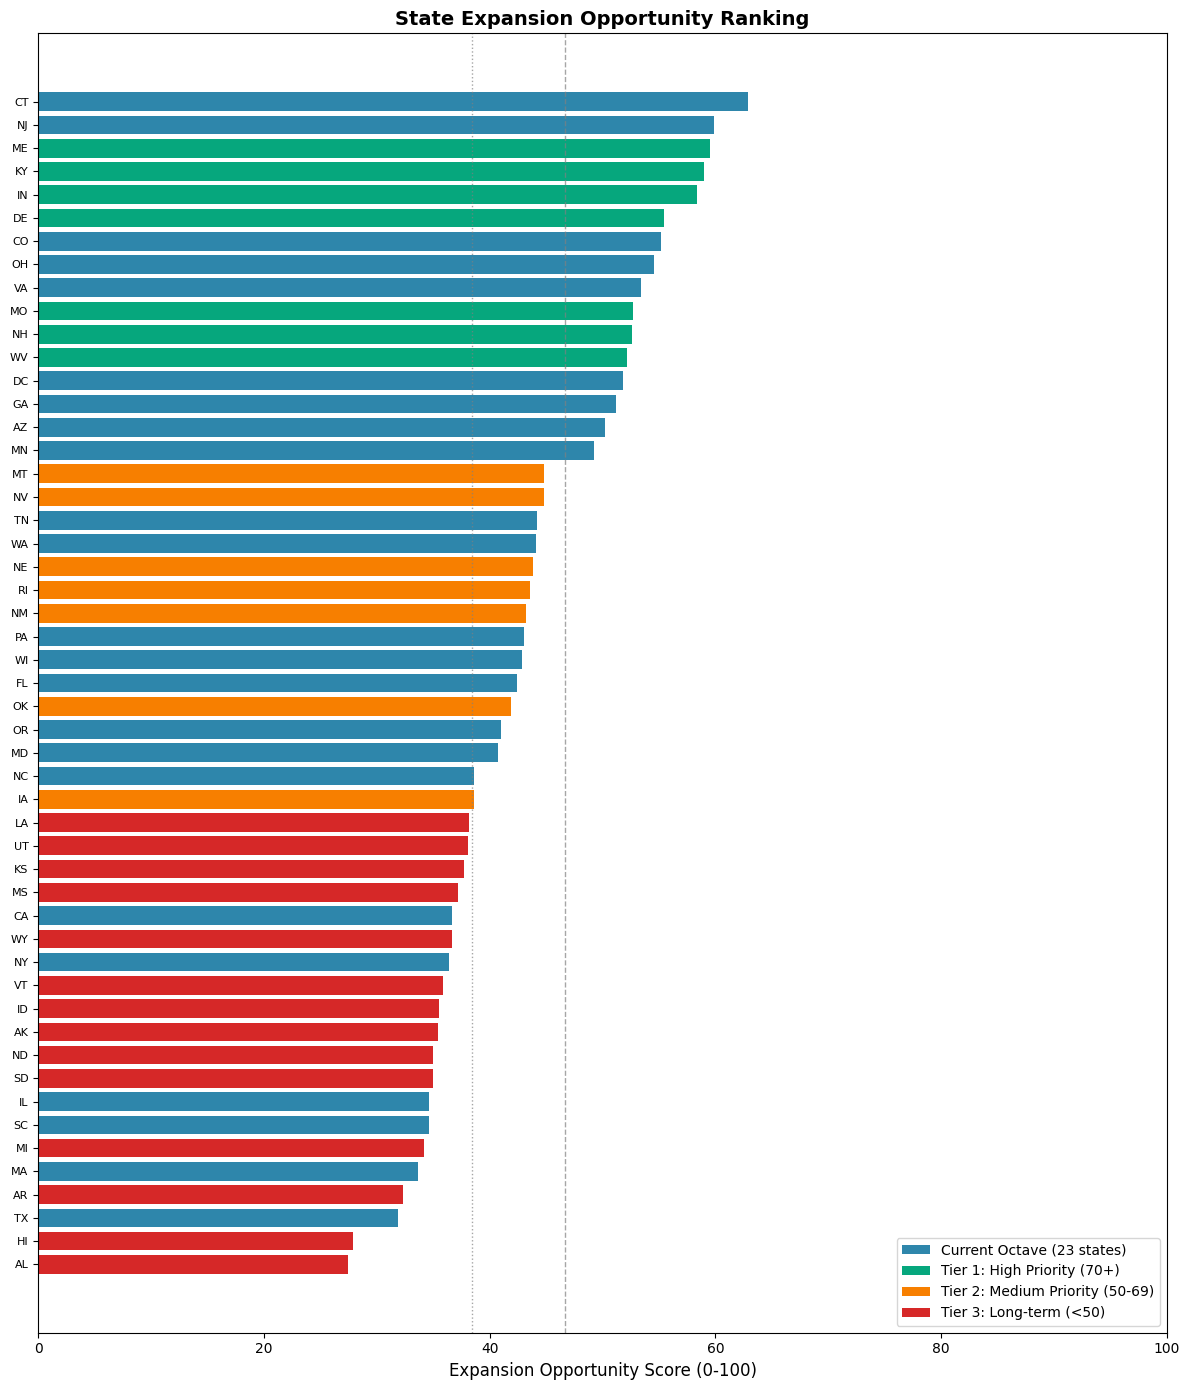

Saved: expansion_opportunity_ranking.png


In [11]:
# --- Visualization 1: All 51 States Ranked by Opportunity Score ---

df_plot = df_master.sort_values('expansion_opportunity_score', ascending=True)

# Color by tier
tier_colors = {
    'Current Octave': '#2E86AB',
    'Tier 1: High Priority': '#06A77D',
    'Tier 2: Medium Priority': '#F77F00',
    'Tier 3: Long-term': '#D62828'
}
colors = [tier_colors[tier] for tier in df_plot['expansion_tier']]

fig, ax = plt.subplots(figsize=(12, 14))

ax.barh(df_plot['state_abbrev'], df_plot['expansion_opportunity_score'], color=colors)
ax.axvline(x=p75, color='gray', linestyle='--', linewidth=1, alpha=0.7, label=f'Tier 1 Threshold ({p75:.0f})')
ax.axvline(x=p50, color='gray', linestyle=':', linewidth=1, alpha=0.7, label=f'Tier 2 Threshold ({p50:.0f})')

ax.set_xlabel('Expansion Opportunity Score (0-100)', fontsize=12)
ax.set_title('State Expansion Opportunity Ranking', fontsize=14, fontweight='bold')
ax.set_xlim(0, 100)
ax.tick_params(axis='y', labelsize=8)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2E86AB', label='Current Octave (23 states)'),
    Patch(facecolor='#06A77D', label='Tier 1: High Priority (70+)'),
    Patch(facecolor='#F77F00', label='Tier 2: Medium Priority (50-69)'),
    Patch(facecolor='#D62828', label='Tier 3: Long-term (<50)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'expansion_opportunity_ranking.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: expansion_opportunity_ranking.png")

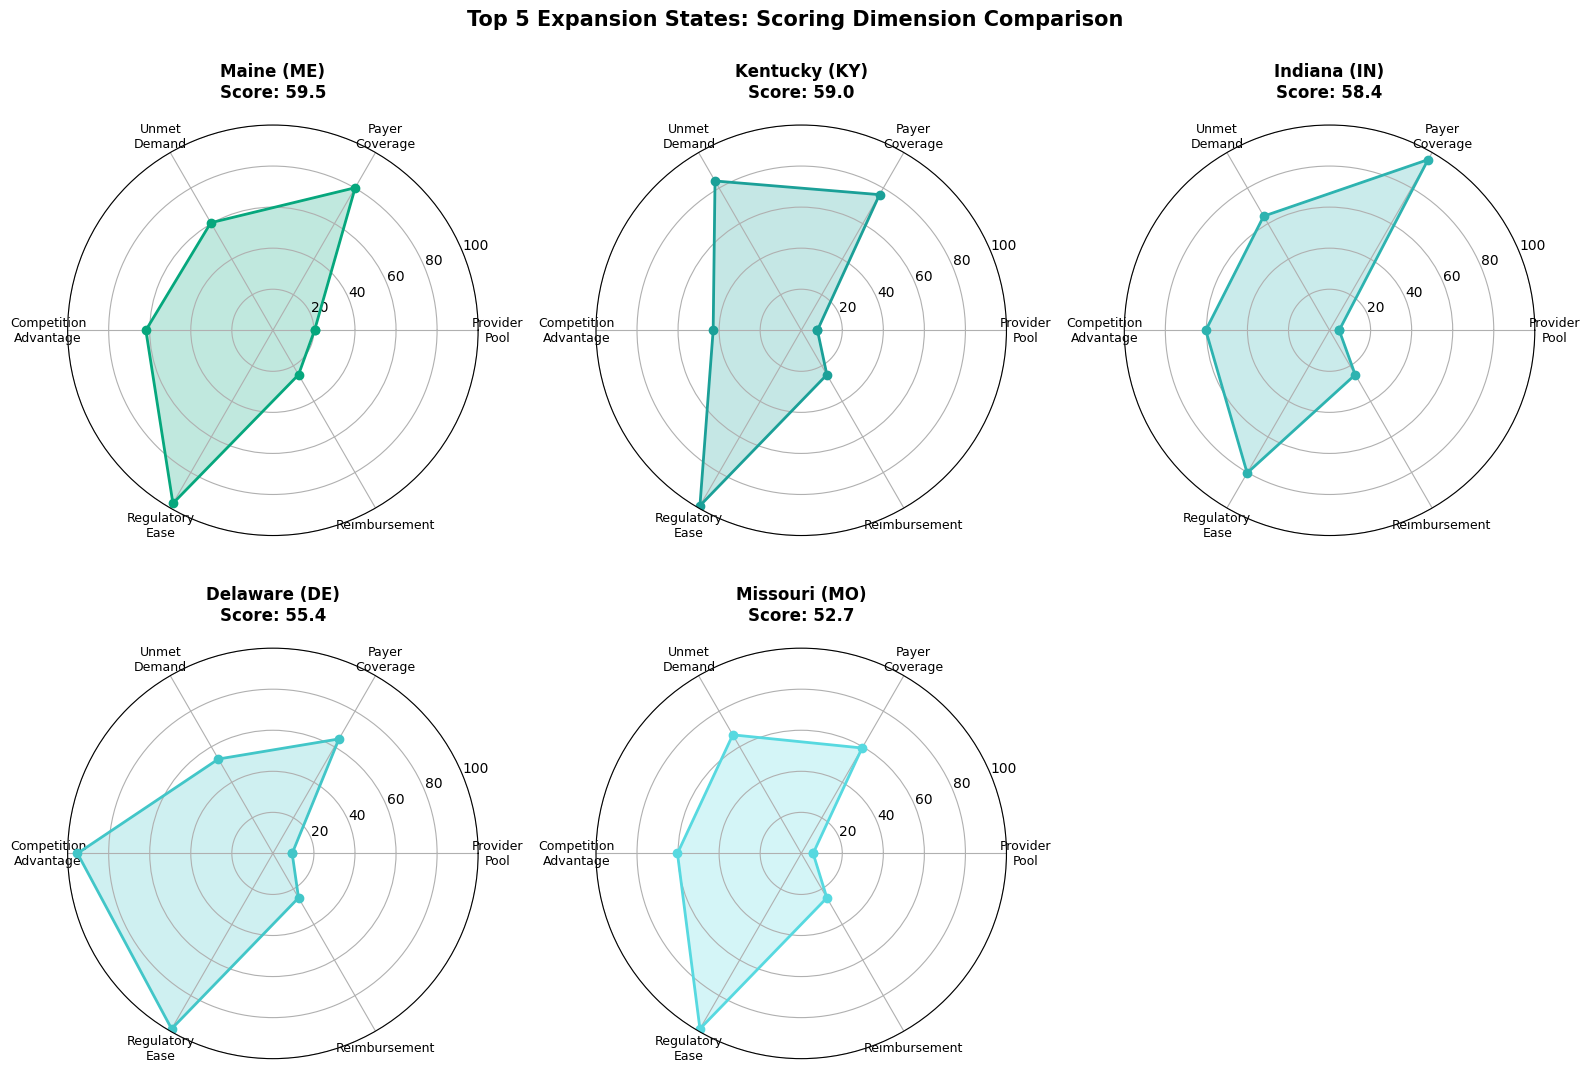

Saved: top5_radar_comparison.png


In [12]:
# --- Visualization 2: Radar Chart Comparing Top 5 Expansion States ---

from math import pi

# State abbreviation to full name mapping
STATE_NAMES = dict(zip(df_master['state_abbrev'], df_master['state_name']))

# Top 5 expansion states (not current Octave)
top5_expansion = df_master[
    ~df_master['is_octave_state']
].nlargest(5, 'expansion_opportunity_score')[[
    'state_abbrev', 'state_name', 'expansion_opportunity_score',
    'provider_pool_score', 'payer_coverage_score',
    'unmet_demand_score', 'competitive_advantage_score', 'regulatory_score', 'reimbursement_score'
]]

# Set up radar chart
categories = ['Provider\nPool', 'Payer\nCoverage', 'Unmet\nDemand', 
              'Competition\nAdvantage', 'Regulatory\nEase', 'Reimbursement']
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, axes = plt.subplots(2, 3, figsize=(16, 11), subplot_kw=dict(projection='polar'))
axes = axes.flatten()

colors_radar = ['#06A77D', '#1BA098', '#2DB3B0', '#42C6C8', '#57D9E0']

for idx, (i, row) in enumerate(top5_expansion.iterrows()):
    ax = axes[idx]
    
    values = [
        row['provider_pool_score'],
        row['payer_coverage_score'],
        row['unmet_demand_score'],
        row['competitive_advantage_score'],
        row['regulatory_score'],
        row['reimbursement_score']
    ]
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2, color=colors_radar[idx])
    ax.fill(angles, values, alpha=0.25, color=colors_radar[idx])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=9)
    ax.set_ylim(0, 100)
    ax.set_title(f"{row['state_name']} ({row['state_abbrev']})\nScore: {row['expansion_opportunity_score']:.1f}",
                 size=12, fontweight='bold', pad=20)
    ax.grid(True)

# Remove extra subplot
fig.delaxes(axes[5])

plt.suptitle('Top 5 Expansion States: Scoring Dimension Comparison', fontsize=15, fontweight='bold', y=0.99)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'top5_radar_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: top5_radar_comparison.png")


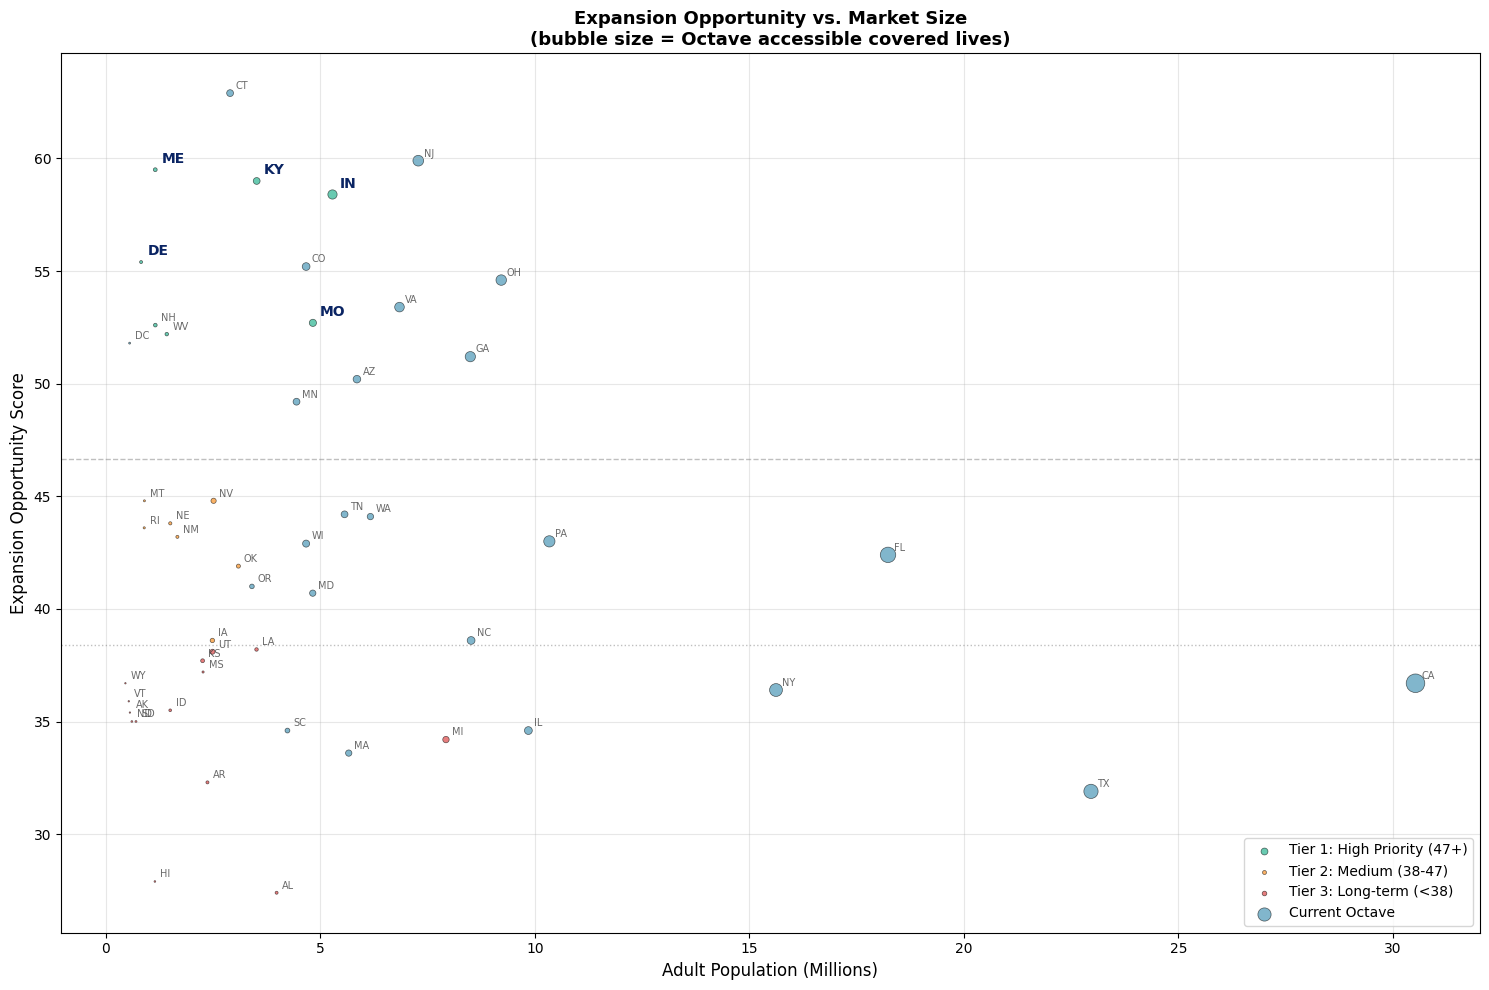

Saved: opportunity_vs_population.png


In [13]:
# --- Visualization 3: Scatter - Opportunity Score vs. Population (bubble = covered lives) ---

fig, ax = plt.subplots(figsize=(15, 10))

# Separate Octave and expansion states
octave = df_master[df_master['is_octave_state']]
expansion = df_master[~df_master['is_octave_state']]

# Expansion states colored by tier
tier1 = expansion[expansion['expansion_tier'] == 'Tier 1: High Priority']
tier2 = expansion[expansion['expansion_tier'] == 'Tier 2: Medium Priority']
tier3 = expansion[expansion['expansion_tier'] == 'Tier 3: Long-term']

def scatter_tier(df, label, color, ax=ax):
    ax.scatter(
        df['population_18_plus'] / 1e6,
        df['expansion_opportunity_score'],
        s=df['octave_accessible_covered_lives'] / 30000,  # Scale for visibility
        alpha=0.6,
        color=color,
        label=label,
        edgecolors='black',
        linewidth=0.5
    )

scatter_tier(tier1, f'Tier 1: High Priority ({p75:.0f}+)', '#06A77D')
scatter_tier(tier2, f'Tier 2: Medium ({p50:.0f}-{p75:.0f})', '#F77F00')
scatter_tier(tier3, f'Tier 3: Long-term (<{p50:.0f})', '#D62828')
scatter_tier(octave, 'Current Octave', '#2E86AB')

ax.set_xlabel('Adult Population (Millions)', fontsize=12)
ax.set_ylabel('Expansion Opportunity Score', fontsize=12)
ax.set_title('Expansion Opportunity vs. Market Size\n(bubble size = Octave accessible covered lives)', fontsize=13, fontweight='bold')
ax.axhline(y=p75, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(y=p50, color='gray', linestyle=':', alpha=0.5, linewidth=1)
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right', fontsize=10)

# Top 5 expansion states get dark blue bold labels
top5_abbrevs = set(tier1.nlargest(5, 'expansion_opportunity_score')['state_abbrev'].tolist())

# Label ALL states
for _, row in df_master.iterrows():
    x = row['population_18_plus'] / 1e6
    y = row['expansion_opportunity_score']
    abbrev = row['state_abbrev']
    
    if abbrev in top5_abbrevs:
        ax.annotate(abbrev, (x, y), fontsize=10, fontweight='bold', color='#0A2463',
                    xytext=(5, 5), textcoords='offset points')
    else:
        ax.annotate(abbrev, (x, y), fontsize=7, color='#444444', alpha=0.8,
                    xytext=(4, 3), textcoords='offset points')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'opportunity_vs_population.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: opportunity_vs_population.png")


## 8. Save Expansion Scores

In [14]:
# Select all relevant columns for output
output_cols = [
    'state_name', 'state_abbrev', 'is_octave_state',
    'total_population', 'population_18_plus', 'commercial_population',
    'total_bh_providers', 'providers_per_100k', 'total_therapy_providers', 'total_prescribers',
    'octave_accessible_covered_lives', 'octave_raw_payer_lives', 'accessible_penetration_pct',
    'has_bcbs_partner', 'n_octave_payers',
    'treatment_gap_pct', 'treatment_gap_population', 'ami_prevalence_pct',
    'competitive_intensity_score', 'broadband_pct',
    'compact_score', 'regulatory_ease_score', 'reimbursement_favorability',
    'telehealth_parity', 'medicare_90837_rate',
    'provider_pool_score', 'payer_coverage_score', 'unmet_demand_score',
    'competitive_advantage_score', 'regulatory_score', 'reimbursement_score',
    'expansion_opportunity_score', 'expansion_tier'
]

df_output = df_master[output_cols].sort_values('expansion_opportunity_score', ascending=False)

output_path = os.path.join(OUTPUT_DIR, 'state_expansion_scores.csv')
df_output.to_csv(output_path, index=False)

print(f"Saved: {output_path}")
print(f"Shape: {df_output.shape}")
print(f"\nTop 15 Expansion Opportunities:")
top_exp = df_output[~df_output['is_octave_state']].head(15)
print(f"{'Rank':<6} {'State':<25} {'Score':>7} {'Tier':<25} {'Access Lives':>14} {'Treatment Gap':>14}")
print('-' * 95)
for rank, (idx, row) in enumerate(top_exp.iterrows(), 1):
    print(f"{rank:<6} {row['state_abbrev'] + ' ' + row['state_name']:<25} {row['expansion_opportunity_score']:>7.1f} {row['expansion_tier']:<25} {row['octave_accessible_covered_lives']:>14,.0f} {row['treatment_gap_pct']:>13.1f}%")


Saved: /Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/octave_behavioral_health_expansion/data/outputs/nb07_expansion_scoring/state_expansion_scores.csv
Shape: (51, 33)

Top 15 Expansion Opportunities:
Rank   State                       Score Tier                        Access Lives  Treatment Gap
-----------------------------------------------------------------------------------------------
1      ME Maine                     59.5 Tier 1: High Priority            233,962          57.7%
2      KY Kentucky                  59.0 Tier 1: High Priority            727,660          61.5%
3      IN Indiana                   58.4 Tier 1: High Priority          1,342,630          58.3%
4      DE Delaware                  55.4 Tier 1: High Priority            142,778          56.5%
5      MO Missouri                  52.7 Tier 1: High Priority            810,457          58.7%
6      NH New Hampshire             52.6 Tier 1: 

---

## Summary

**Expansion Opportunity Scoring Complete**

- All 51 states ranked by composite opportunity score (0-100)
- Segmented into 4 tiers: Current Octave (23), Tier 1 (high priority ≥70), Tier 2 (medium 50-69), Tier 3 (long-term <50)
- Model validated: Current Octave states score higher on average, confirming alignment
- Key output: `state_expansion_scores.csv` with all normalized scores and composite ranking

**Next: NB08 — Covered Lives & Provider Projections**

NB08 uses the expansion scores to model incremental revenue, provider recruitment, and expansion wave planning.